# **Stacked Charts**


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [2]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-02-05 09:05:59--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  73.9MB/s    in 2.1s    

2026-02-05 09:06:01 (73.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Load the data


In [3]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [4]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



In [5]:
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}
df['Age_numeric'] = df['Age'].map(age_map)

In [6]:
job_sat_summary = df.groupby('Age_numeric').agg(
    MedianJobSat6=('JobSatPoints_6', 'median'),
    MedianJobSat7=('JobSatPoints_7', 'median')
).reset_index()

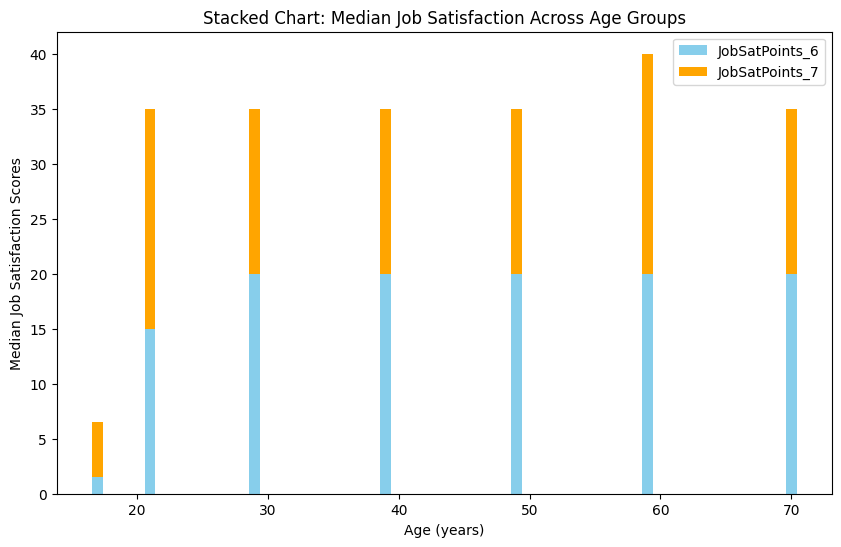

In [7]:
plt.figure(figsize=(10,6))

# Plot stacked bars
plt.bar(job_sat_summary['Age_numeric'], job_sat_summary['MedianJobSat6'], label='JobSatPoints_6', color='skyblue')
plt.bar(job_sat_summary['Age_numeric'], job_sat_summary['MedianJobSat7'], 
        bottom=job_sat_summary['MedianJobSat6'], label='JobSatPoints_7', color='orange')

plt.title("Stacked Chart: Median Job Satisfaction Across Age Groups")
plt.xlabel("Age (years)")
plt.ylabel("Median Job Satisfaction Scores")
plt.legend()

##### Insights:
- Younger respondents may show higher satisfaction in one category compared to older groups.
- The stacked format highlights relative contributions of JobSatPoints_6 vs. JobSatPoints_7 within each age group.
- You can quickly spot which age groups lean more toward one satisfaction measure.

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


In [8]:
job_sat_employment = df.groupby('Employment').agg(
    MedianJobSat6=('JobSatPoints_6', 'median'),
    MedianJobSat7=('JobSatPoints_7', 'median')
).reset_index()

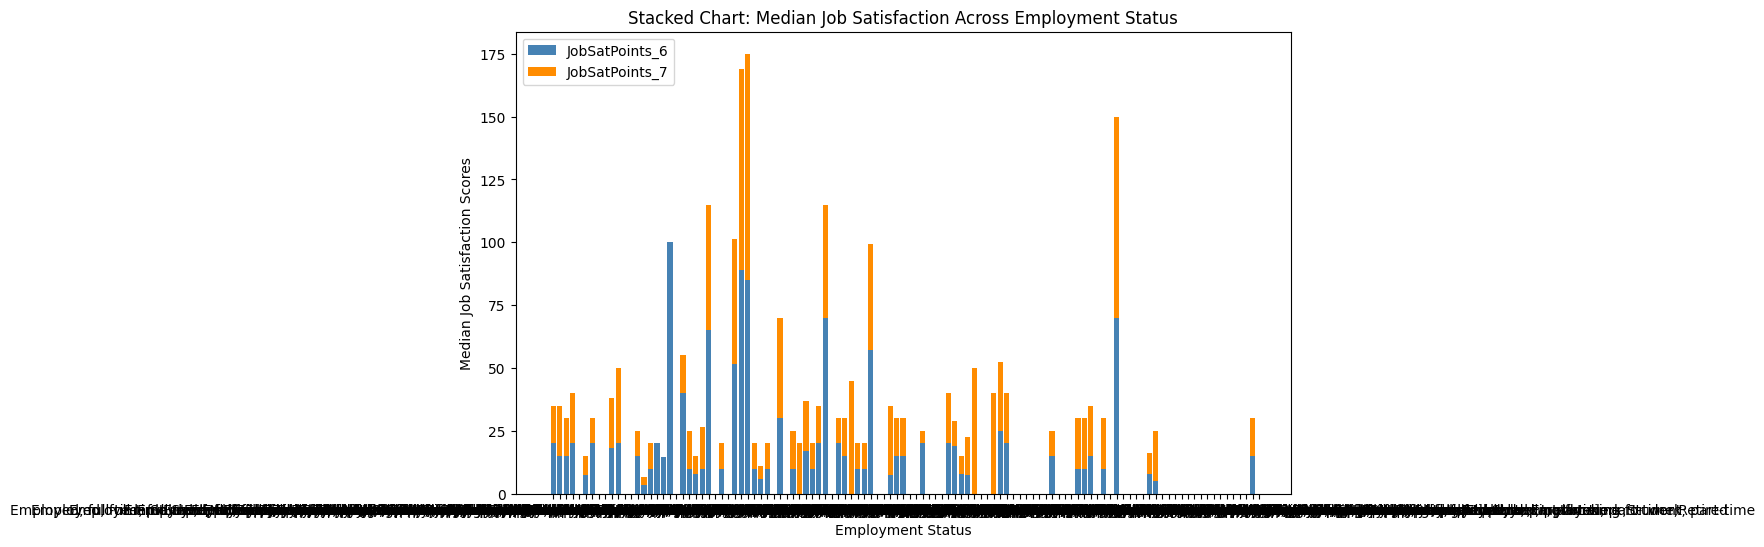

In [14]:
plt.figure(figsize=(10,6))

# Plot stacked bars
plt.bar(job_sat_employment['Employment'], 
        job_sat_employment['MedianJobSat6'], 
        label='JobSatPoints_6', color='steelblue')

plt.bar(job_sat_employment['Employment'], 
        job_sat_employment['MedianJobSat7'], 
        bottom=job_sat_employment['MedianJobSat6'], 
        label='JobSatPoints_7', color='darkorange')

plt.title("Stacked Chart: Median Job Satisfaction Across Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Median Job Satisfaction Scores")
plt.legend()

##### Insights: 
- Full-time employees may show higher satisfaction in one category compared to freelancers or students.
- The stacked format highlights relative contributions of JobSatPoints_6 vs. JobSatPoints_7 within each employment type.
- You can quickly spot which employment groups lean more toward one satisfaction measure.

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


In [19]:
# Filter respondents aged 30–35
df_age30_35 = df[(df['Age_numeric'] >= 30) & (df['Age_numeric'] <= 35)]

In [22]:

df_age30_35 = df[(df['Age_numeric'] >= 30) & (df['Age_numeric'] <= 35)]


In [23]:

median_comp = df_age30_35['ConvertedCompYearly'].median()
median_jobsat = df_age30_35['JobSatPoints_6'].median()


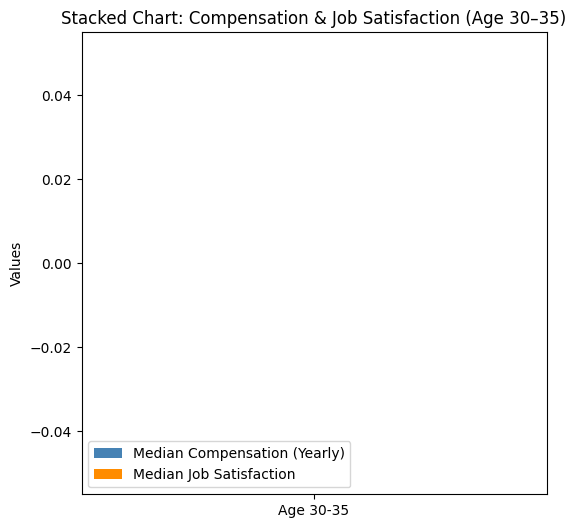

In [24]:


plt.figure(figsize=(6,6))

# Stacked bar with two components
plt.bar(['Age 30-35'], median_comp, label='Median Compensation (Yearly)', color='steelblue')
plt.bar(['Age 30-35'], median_jobsat, bottom=median_comp, label='Median Job Satisfaction', color='darkorange')

plt.title("Stacked Chart: Compensation & Job Satisfaction (Age 30–35)")
plt.ylabel("Values")
plt.legend()
plt.show()



##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


In [25]:
age_summary = df.groupby('Age_numeric').agg(
    MedianComp=('ConvertedCompYearly', 'median'),
    MedianJobSat=('JobSatPoints_6', 'median')
).reset_index()

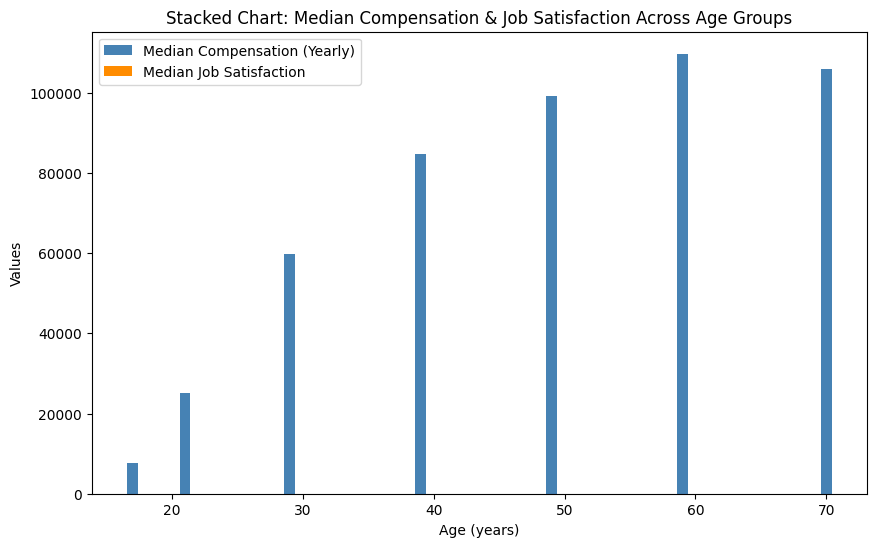

In [27]:
plt.figure(figsize=(10,6))

# Compensation at bottom, Job Satisfaction stacked above
plt.bar(age_summary['Age_numeric'], 
        age_summary['MedianComp'], 
        label='Median Compensation (Yearly)', color='steelblue')

plt.bar(age_summary['Age_numeric'], 
        age_summary['MedianJobSat'], 
        bottom=age_summary['MedianComp'], 
        label='Median Job Satisfaction', color='darkorange')

plt.title("Stacked Chart: Median Compensation & Job Satisfaction Across Age Groups")
plt.xlabel("Age (years)")
plt.ylabel("Values")
plt.legend()

##### Insights: 
- Younger respondents may show lower compensation but relatively higher satisfaction.
- Mid-career groups (30–40s) often show higher compensation but variable satisfaction.
- Older groups may show stable compensation but potentially declining satisfaction.

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [28]:
# Split multiple databases into separate rows
df_db = df.assign(DatabaseWantToWorkWith=df['DatabaseWantToWorkWith'].str.split(';')).explode('DatabaseWantToWorkWith')
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.strip()

In [29]:
age_map = {
    "Under 18 years old": "Under 18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}
df_db['AgeGroup'] = df_db['Age'].map(age_map)

In [30]:
db_summary = df_db.groupby(['AgeGroup','DatabaseWantToWorkWith']).size().reset_index(name='Count')

In [31]:
db_pivot = db_summary.pivot(index='AgeGroup', columns='DatabaseWantToWorkWith', values='Count').fillna(0)

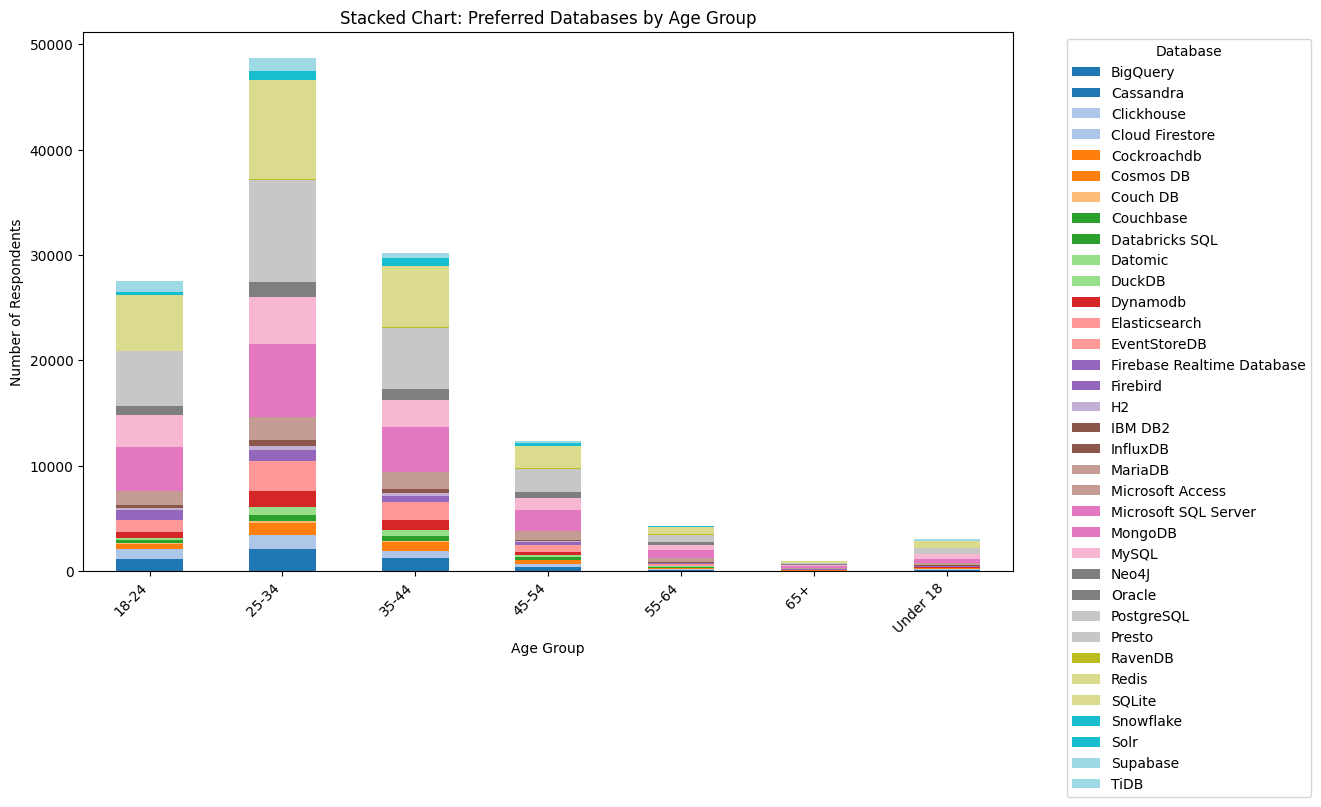

In [32]:
db_pivot.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')

plt.title("Stacked Chart: Preferred Databases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.legend(title="Database", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha="right")
plt.show()

##### Insights: 
- Younger respondents may lean toward open-source databases like MySQL and PostgreSQL.
- Mid-career professionals often show stronger interest in enterprise databases like SQL Server or Oracle.
- The stacked format makes it easy to compare relative proportions of database preferences across age groups.

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [34]:
# Group by Job Satisfaction and Employment
job_sat_emp = df.groupby(['JobSatPoints_6','Employment']).size().reset_index(name='Count')

job_sat_pivot = job_sat_emp.pivot(index='JobSatPoints_6', columns='Employment', values='Count').fillna(0)

<Figure size 1200x700 with 0 Axes>

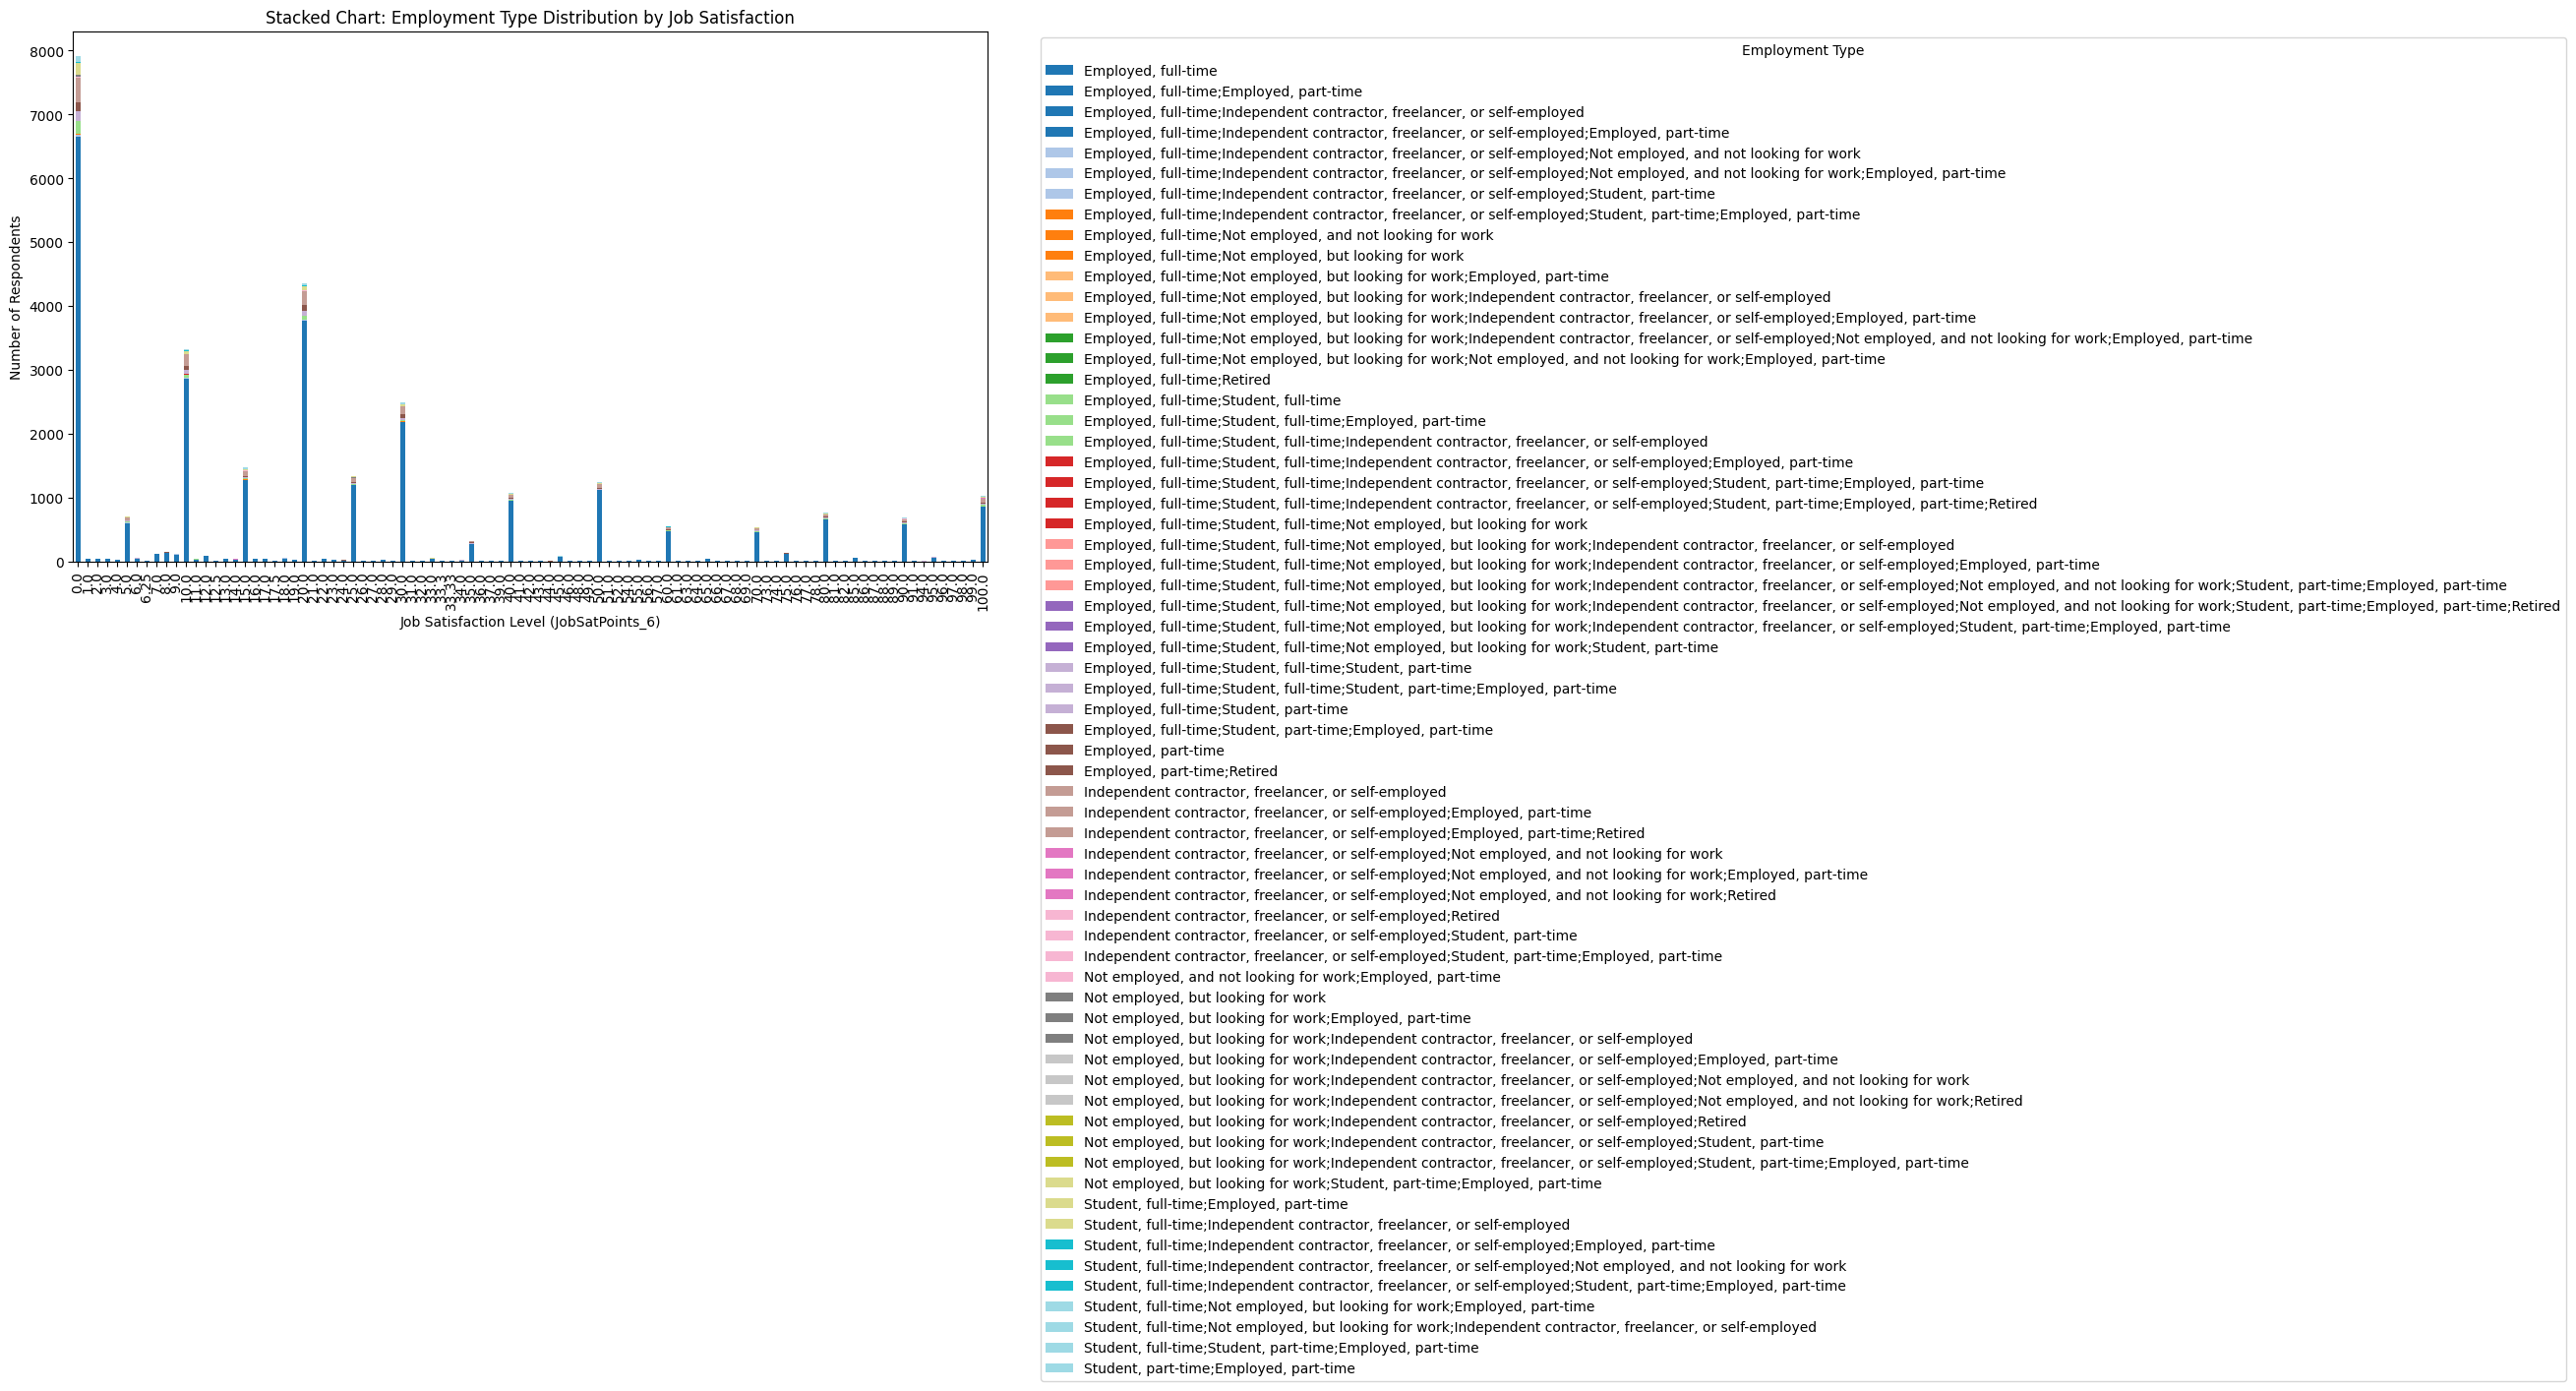

In [41]:
plt.figure(figsize=(12,7))

# Plot stacked bar chart
job_sat_pivot.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')

plt.title("Stacked Chart: Employment Type Distribution by Job Satisfaction")
plt.xlabel("Job Satisfaction Level (JobSatPoints_6)")
plt.ylabel("Number of Respondents")
plt.legend(title="Employment Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [42]:
# Split multiple admired languages into separate rows
df_lang = df.assign(LanguageAdmired=df['LanguageAdmired'].str.split(';')).explode('LanguageAdmired')
df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.strip()

In [44]:
age_map = {
    "Under 18 years old": "Under 18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}
df_lang['AgeGroup'] = df_lang['Age'].map(age_map)

In [46]:
lang_summary = df_lang.groupby(['AgeGroup','LanguageAdmired']).size().reset_index(name='Count')

lang_pivot = lang_summary.pivot(index='AgeGroup', columns='LanguageAdmired', values='Count').fillna(0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '18-24'),
  Text(1, 0, '25-34'),
  Text(2, 0, '35-44'),
  Text(3, 0, '45-54'),
  Text(4, 0, '55-64'),
  Text(5, 0, '65+'),
  Text(6, 0, 'Under 18')])

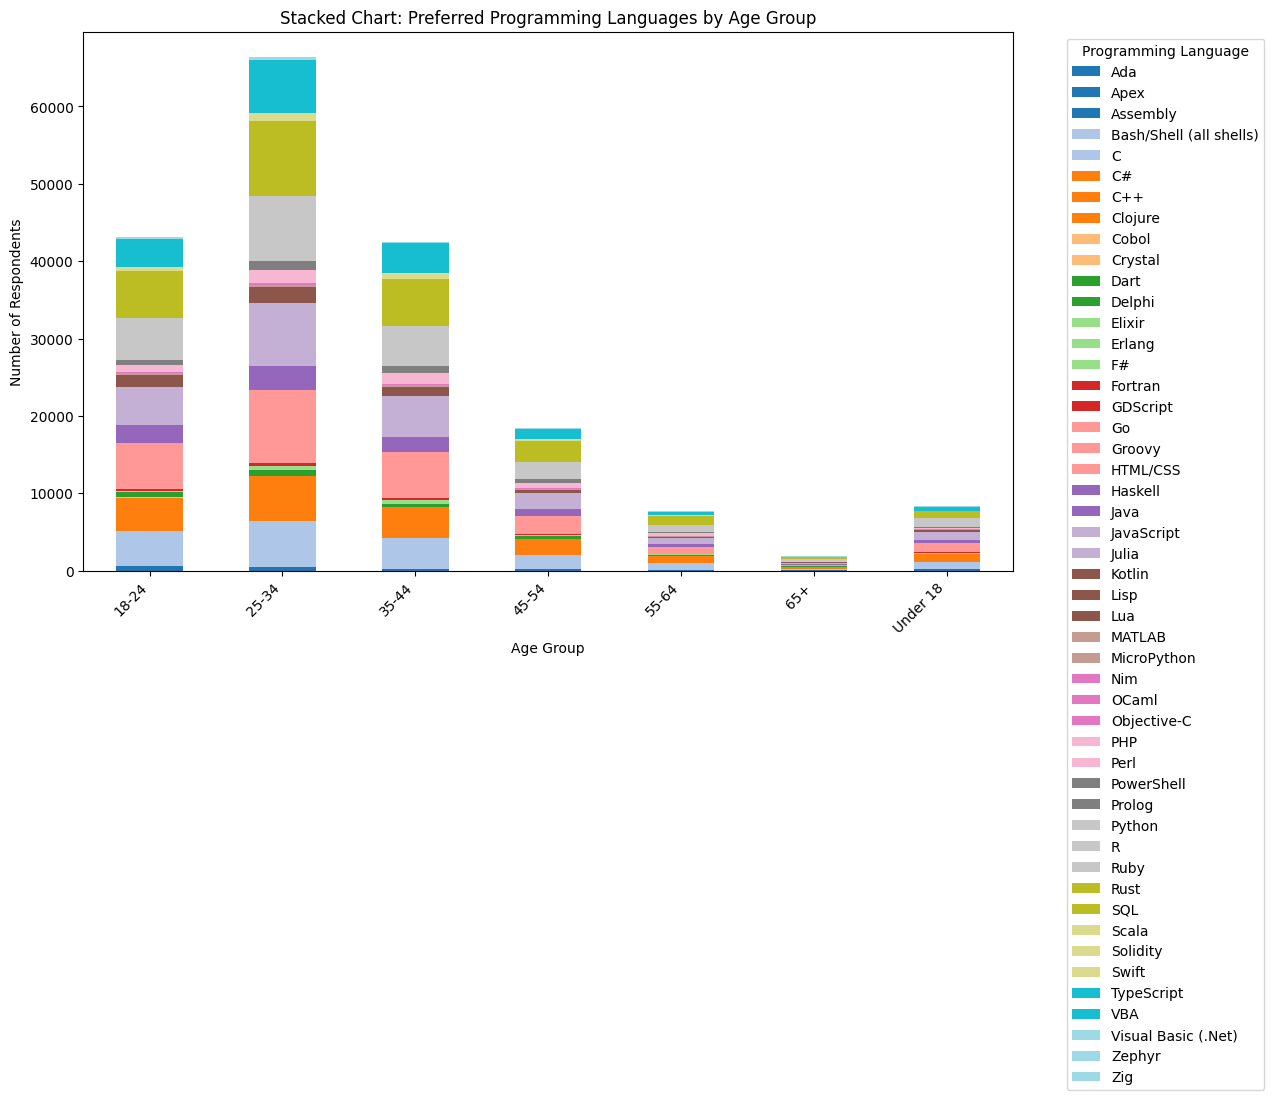

In [47]:
# Plot stacked bar chart
lang_pivot.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')

plt.title("Stacked Chart: Preferred Programming Languages by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.legend(title="Programming Language", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha="right")

##### Insights: 
- Younger respondents (18–24) often admire Python and JavaScript due to accessibility and versatility.
- Mid-career groups (25–34, 35–44) may show stronger admiration for enterprise languages like Java or C#.
- Older groups sometimes admire stable, long-standing languages (e.g., C, SQL) but also show curiosity toward modern ones like Rust.
- The stacked format makes it easy to compare relative proportions of language admiration across age groups.

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [48]:
# Split multiple admired platforms into separate rows
df_platform = df.assign(PlatformAdmired=df['PlatformAdmired'].str.split(';')).explode('PlatformAdmired')
df_platform['PlatformAdmired'] = df_platform['PlatformAdmired'].str.strip()

In [49]:
platform_summary = df_platform.groupby(['Employment','PlatformAdmired']).size().reset_index(name='Count')

In [50]:
platform_pivot = platform_summary.pivot(index='Employment', columns='PlatformAdmired', values='Count').fillna(0)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
        85, 86]),
 [Text(0, 0, 'Employed, full-time'),
  Text(1, 0, 'Employed, full-time;Employed, part-time'),
  Text(2, 0, 'Employed, full-time;Independent contractor, freelancer, or self-employed'),
  Text(3, 0, 'Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time'),
  Text(4, 0, 'Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work'),
  Text(5, 0, 'Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time'),
  Text(6, 0, 'Employed, full-t

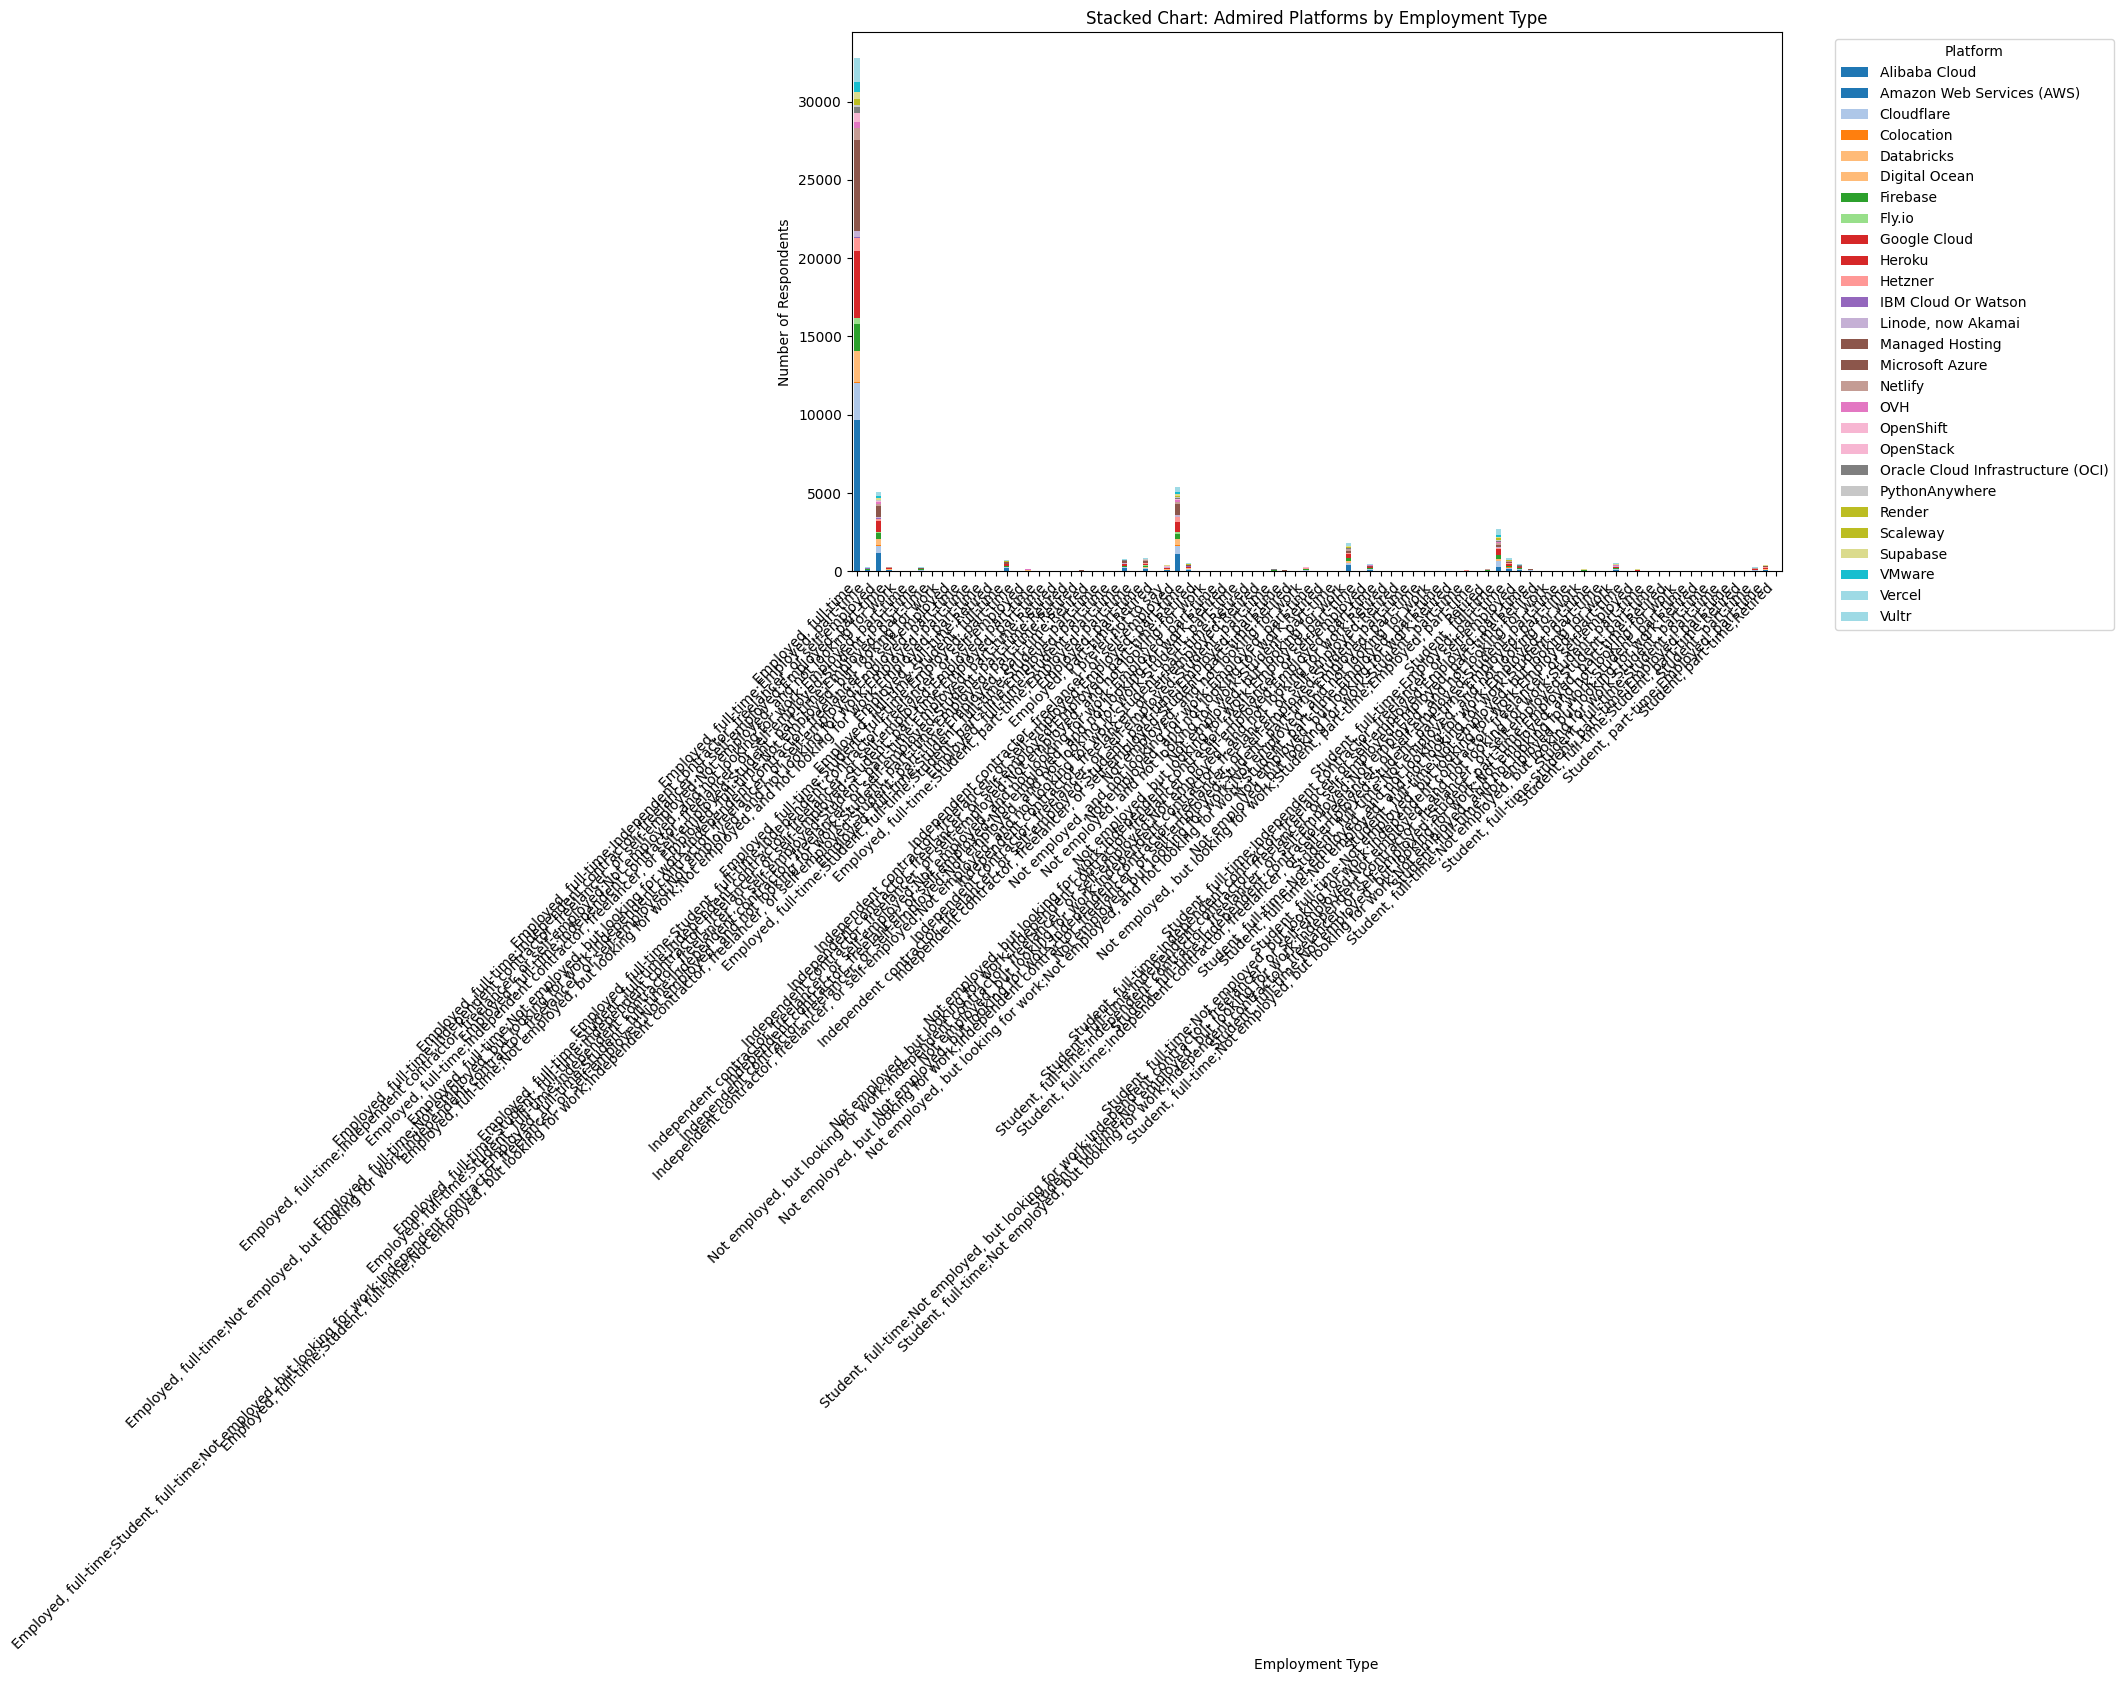

In [51]:
# Plot stacked bar chart
platform_pivot.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')

plt.title("Stacked Chart: Admired Platforms by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Respondents")
plt.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha="right")

## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
